In [88]:
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, glob, sys
from sklearn.metrics import r2_score, auc, f1_score, fbeta_score, precision_recall_fscore_support, precision_recall_curve, classification_report
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay, brier_score_loss
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
import joblib

Load test file

In [25]:
day_start = '2016-01-01'
day_end = '2018-01-01'
# Load test
X_test = xr.open_dataset('features_test_sample_{ds}-{de}.nc'.format(ds=day_start,de=day_end))
X_test['X'] = X_test['__xarray_dataarray_variable__']
X_test = X_test.drop(['__xarray_dataarray_variable__'])
y_test = xr.open_dataset('targets_test_sample_{ds}-{de}.nc'.format(ds=day_start,de=day_end))
y_test['y'] = y_test['__xarray_dataarray_variable__']
y_test = y_test.drop(['__xarray_dataarray_variable__'])
y_test_calc = y_test['y'].values
X_test_calc = X_test['X'].values
# Load train
X_train = xr.open_dataset('features_training_sample_{ds}-{de}.nc'.format(ds=day_start,de=day_end))
X_train['X'] = X_train['__xarray_dataarray_variable__']
X_train = X_train.drop(['__xarray_dataarray_variable__'])
y_train = xr.open_dataset('targets_training_sample_{ds}-{de}.nc'.format(ds=day_start,de=day_end))
y_train['y'] = y_train['__xarray_dataarray_variable__']
y_train = y_train.drop(['__xarray_dataarray_variable__'])
#
X_train_calc = X_train['X'].values
features = X_train_calc.reshape(X_train_calc.shape[0]*X_train_calc.shape[1]*X_train_calc.shape[2],
                                X_train_calc.shape[3])
y_train_calc = y_train['y'].values


/tmp/ipykernel_3314206/3346537202.py:6: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  X_test = X_test.drop(['__xarray_dataarray_variable__'])
/tmp/ipykernel_3314206/3346537202.py:9: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  y_test = y_test.drop(['__xarray_dataarray_variable__'])
/tmp/ipykernel_3314206/3346537202.py:15: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  X_train = X_train.drop(['__xarray_dataarray_variable__'])
/tmp/ipykernel_3314206/3346537202.py:18: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  y_train = y_train.drop(['__xarray_dataarray_variable__'])


In [26]:
y_train_bin = y_train_calc
y_train_bin[y_train_bin > 0] = 1
#
y_test_bin = y_test_calc
y_test_bin[y_test_bin > 0] = 1
#
labels = y_train_bin.reshape(y_train_bin.shape[0],y_train_bin.shape[1]*y_train_bin.shape[2])

Load model

In [16]:
model_load = joblib.load("test_rf_model_5day_class.pkl")

In [17]:
X_test_calc = X_test['X'].values
X_test_calc.shape
test_features = X_test_calc.reshape(X_test_calc.shape[0]*X_test_calc.shape[1]*X_test_calc.shape[2],
                                X_test_calc.shape[3])

In [18]:
y_pred = model_load.predict(X_test_calc.reshape(X_test_calc.shape[0]*X_test_calc.shape[1]*X_test_calc.shape[2],
                                                X_test_calc.shape[3]).transpose())
#
y_pred_rs = y_pred.reshape(y_test['y'].shape[0],y_test['y'].shape[1],y_test['y'].shape[2])

In [27]:
training_score = model_load.score(features.transpose(),labels)
print('training score is ',training_score)

training score is  0.00029819306854864764


/home/mmcgraw/miniconda3/envs/tcfp_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1592: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))


In [20]:
from sklearn.metrics import confusion_matrix
#f1 = f1_score(y_test['y'].values[:,75,120],y_pred_rs[:,75,120])

In [31]:
#result = permutation_importance(model_load, features.transpose(), labels, n_repeats=3)
y_true = y_test_bin.reshape(y_test_bin.shape[0],y_test_bin.shape[1]*y_test_bin.shape[2])

In [32]:
cm = confusion_matrix(y_pred.reshape(y_pred.shape[0]*y_pred.shape[1]),
                                     y_true.reshape(y_true.shape[0]*y_true.shape[1]))

In [44]:
def calc_CM_stats(label_names,labels,ncats,cm):
    cm_stats_ALL = pd.DataFrame()
    for i in np.arange(0,ncats):
        cm_stats = pd.DataFrame(index=[i],columns=['Category','Category Names','N_predicted','N_actual','Hits','False Alarms',
                                                         'Misses','Correct Negs','POD','FAR','PFOD','SR','Threat'])
        #
       # print(labels_name[i])
        cm_stats['Category Names'] = label_names[i]
        cm_stats['Category'] = labels[i]
        cm_stats['N_predicted'] = cm.sum(axis=0)[i]
        cm_stats['N_actual'] = cm.sum(axis=1)[i]
        cm_stats['Hits'] = np.diag(cm)[i]
        cm_stats['False Alarms'] = np.sum(cm[:,i]) - cm[i,i]
        cm_stats['Misses'] = np.sum(cm[i,:]) - cm[i,i]
        cm_negs = np.delete(cm,i,0)
        cm_negs = np.delete(cm_negs,i,1)
        cm_stats['Correct Negs'] = np.sum(cm_negs)
        cm_stats['POD'] = cm_stats['Hits']/(cm_stats['Hits']+cm_stats['Misses'])
        cm_stats['FAR'] = cm_stats['False Alarms']/(cm_stats['False Alarms']+cm_stats['Hits'])
        cm_stats['PFOD'] = cm_stats['False Alarms']/(cm_stats['False Alarms']+cm_stats['Correct Negs'])
        cm_stats['Threat'] = cm_stats['Hits']/(cm_stats['Hits']+cm_stats['Misses']+cm_stats['False Alarms'])
        cm_stats['SR'] = cm_stats['Hits']/(cm_stats['Hits']+cm_stats['False Alarms'])
        cm_stats['BIAS'] = (cm_stats['Hits']+cm_stats['False Alarms'])/(cm_stats['Hits'] + cm_stats['Misses'])
        cm_stats_ALL = pd.concat([cm_stats_ALL,cm_stats])
    #
    return cm_stats_ALL

In [45]:
label_names = ['no genesis','genesis']
labels = model_load.classes_
ncats = 2

In [46]:
cm_stats = calc_CM_stats(label_names,labels,ncats,cm)

In [47]:
cm_stats

,Category,Category Names,N_predicted,N_actual,Hits,False Alarms,Misses,Correct Negs,POD,FAR,PFOD,SR,Threat,BIAS
0,0.0,no genesis,19080307,19024785,18942680,137627,82105,2188,0.995684,0.007213,0.984351,0.992787,0.988533,1.002918
1,0.0,genesis,84293,139815,2188,82105,137627,18942680,0.015649,0.974043,0.004316,0.025957,0.009859,0.602890


In [48]:
class_report = classification_report(y_true,y_pred,output_dict=True)

/home/mmcgraw/miniconda3/envs/tcfp_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/mmcgraw/miniconda3/envs/tcfp_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/mmcgraw/miniconda3/envs/tcfp_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))

In [49]:
crdf = pd.DataFrame(class_report)
crdf

,0,1,2,3,4,5,6,7,8,9,...,32754,32755,32756,32757,32758,32759,micro avg,macro avg,weighted avg,samples avg
precision,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.015649,0.000114,0.001345,0.015649
recall,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.025957,0.003358,0.025957,0.014059
f1-score,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.019526,0.000217,0.002538,0.014399
support,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,84293.000000,84293.000000,84293.000000,84293.000000


In [57]:
features_test = X_test_calc.reshape(X_test_calc.shape[0]*X_test_calc.shape[1]*X_test_calc.shape[2],
                                                X_test_calc.shape[3]).transpose()

ypred_prob = model_load.predict_proba(features_test)
#ypred_prob_rs = ypred_prob.reshape(ypred_prob.shape[0],y_test['y'].shape[1],y_test['y'].shape[2])

In [80]:
brier_loss = [brier_score_loss(y_true.reshape(y_true.shape[0]*y_true.shape[1]),
                               [y for x in range(len(y_true.reshape(y_true.shape[0]*y_true.shape[1])))]) for y in np.arange(0,1.01,0.1)]

In [83]:
bs_ref = np.sum(y_true==1)/len(y_true.reshape(y_true.shape[0]*y_true.shape[1]))
brier = pd.DataFrame()
brier['BS'] = brier_loss
brier['BSref'] = bs_ref
brier['Threshold'] = np.arange(0,1.01,0.1)

<Axes: xlabel='Threshold'>

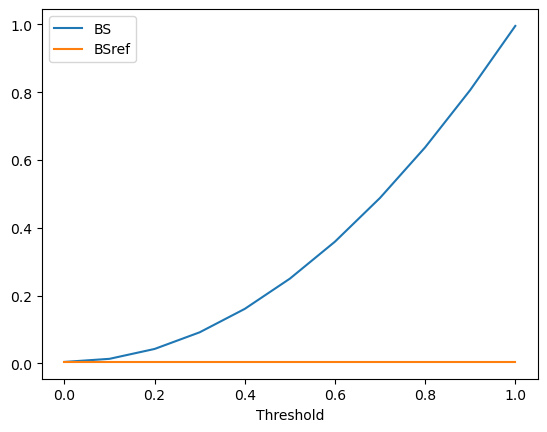

In [85]:
brier.plot(x='Threshold',y=['BS','BSref'])

In [60]:
ypred_prob_rs = ypred_prob.reshape(y_test['y'].shape[0],y_test['y'].shape[1],y_test['y'].shape[2])

AttributeError: 'list' object has no attribute 'reshape'

In [50]:
def get_roc_auc(X_test,basin,model,y_test,class_sel,class_label,scoring,cut='equal'):
    # Probabilistic prediction.  Output is for classes [0,1]
    class_sel = 1
    class_label = 'RI'
    if basin == 'ALL':
        ypred_prob = model.predict_proba(X_test)
        y_test_use = y_test['I_class']
    else:
        ypred_prob = model.predict_proba(X_test.xs(basin))
        y_test_use = y_test['I_class'].xs(basin)
    # Everything for RI only
    y_scores_RI = ypred_prob[:,class_sel]
    # Get Brier Skill Score
    brier_loss = [brier_score_loss(y_test_use,[y for x in range(len(y_test_use))]) for y in np.arange(0,1.01,0.1)]
    BS_ref = np.sum(y_test_use==1)/len((y_test_use))
    #
    brier = pd.DataFrame()
    brier['BS'] = brier_loss
    brier['BASIN'] = basin
    brier['CLASS'] = class_label
    brier['Threshold'] = np.arange(0,1.01,0.1)
    brier['BS_ref'] = BS_ref
    #
    p, r, thresholds = precision_recall_curve(y_test_use,y_scores_RI)
    f1 = (2*p*r)/(p+r)
    p_vs_r = pd.DataFrame(columns={'Precision','Recall','Thresholds','Cutoff Threshold','BASIN','CLASS'})
    p_vs_r['Precision'] = p[:-1]
    p_vs_r['Recall'] = r[:-1]
    p_vs_r['Thresholds'] = thresholds
    p_vs_r['F1'] = f1[:-1]

    # 
    if scoring == 'recall_weighted':
        if cut == 'equal':
            icutoff = np.where(p > r)
            cutoff = icutoff[0][0]
        else:
            icutoff = np.where(np.round(r,1) < 1 - cut)
            cutoff = icutoff[0][0]
    elif scoring == "precision_weighted":
        if cut == 'equal':
            icutoff = np.where(r > p)
            cutoff = icutoff[0][0]
        else:
            icutoff = np.where(np.round(p,1) < 1 - cut)
            cutoff = icutoff[0][0]
    elif scoring == 'f1_weighted':
        mf = p_vs_r['F1'].max()
        imf = p_vs_r.where(p_vs_r['F1'] == mf).dropna(how='all').index
        cutoff = imf[0]
        #cutoff = f1
    pr_thresh = thresholds[cutoff]
    pr_thresh_round = np.round(pr_thresh,1)
    p_vs_r['Cutoff Threshold'] = pr_thresh
    p_vs_r['BASIN'] = basin
    p_vs_r['CLASS'] = class_label
    #
    # ROC AUC curve
    fpr, tpr, auc_thresholds = roc_curve(y_test_use, y_scores_RI)
    auc_roc_score = auc(fpr, tpr)
    recall_RI = recall_score(y_test_use,y_scores_RI >= pr_thresh_round)
    pre_RI = precision_score(y_test_use,y_scores_RI >= pr_thresh_round)
    recall_noRI = recall_score(y_test_use,y_scores_RI < pr_thresh_round)
    pre_noRI = precision_score(y_test_use,y_scores_RI < pr_thresh_round)
    #
    roc_vals = pd.DataFrame(columns={'False Positive Rate','True Positive Rate','AUC Thresholds',
                                 'AUC ROC Score','BASIN','CLASS'})
    roc_vals['False Positive Rate'] = fpr
    roc_vals['True Positive Rate'] = tpr
    roc_vals['AUC Thresholds'] = auc_thresholds
    roc_vals['AUC ROC Score'] = auc_roc_score
    roc_vals['BASIN'] = basin
    roc_vals['CLASS'] = class_label
    return ypred_prob, p_vs_r, roc_vals, brier

In [89]:
def make_CM_plot(cm,labels,ax_sel,tick_labels):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labels)
    #
    disp.plot(ax=ax_sel,cmap='magma_r')
    ax_sel.set_xlabel('Predicted',fontsize=16)
    ax_sel.set_ylabel('Actual',fontsize=16)
    ax_sel.set_xticklabels(tick_labels,fontsize=16)
    ax_sel.set_yticklabels(tick_labels,fontsize=16)

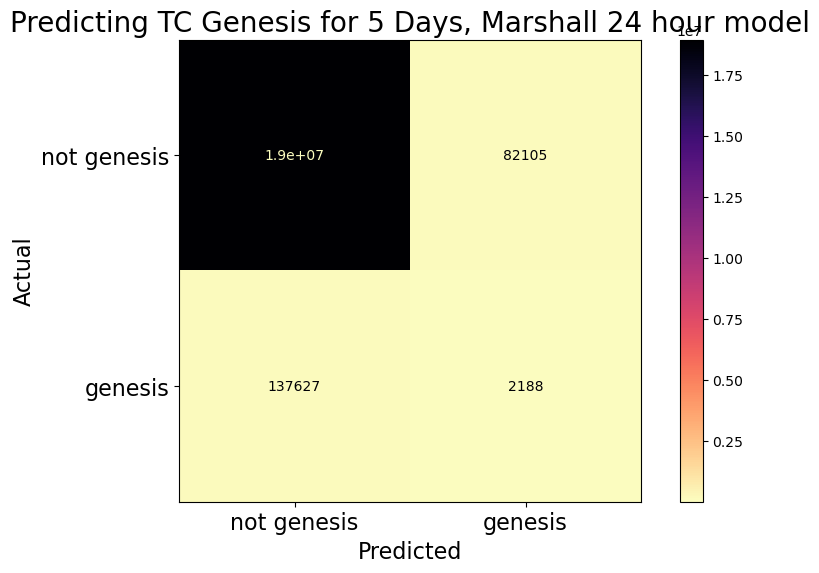

In [100]:
fig1,ax1 = plt.subplots(1,1,figsize=(10,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['not genesis','genesis'])
disp.plot(ax=ax1,cmap='magma_r')
ax1.set_xlabel('Predicted',fontsize=16)
ax1.set_ylabel('Actual',fontsize=16)
ax1.set_xticklabels(['not genesis','genesis'],fontsize=16)
ax1.set_yticklabels(['not genesis','genesis'],fontsize=16)
ax1.set_title('Predicting TC Genesis for 5 Days, Marshall 24 hour model',fontsize=20)
fig1.savefig('5day_confusion_matrix_ex.png',format='png',dpi=300,bbox_inches='tight')

In [128]:
crdf[['micro avg','macro avg','weighted avg','samples avg']]

,micro avg,macro avg,weighted avg,samples avg
precision,0.015649,0.000114,0.001345,0.015649
recall,0.025957,0.003358,0.025957,0.014059
f1-score,0.019526,0.000217,0.002538,0.014399
support,84293.000000,84293.000000,84293.000000,84293.000000


In [ ]:
features = permutation_importance(model_load, test_features.transpose(), y_pred, n_repeats=1)

/home/mmcgraw/miniconda3/envs/tcfp_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1592: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))
/home/mmcgraw/miniconda3/envs/tcfp_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1592: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))
/home/mmcgraw/miniconda3/envs/tcfp_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1592: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "

In [125]:
no_yeses = np.sum(y_test['y'].values > 0)

In [126]:
100*(no_yeses/y_test['y'].size)

0.43983699111904245

In [131]:
cm_stats
cm_gen = cm_stats.loc[1]

,Category,Category Names,N_predicted,N_actual,Hits,False Alarms,Misses,Correct Negs,POD,FAR,PFOD,SR,Threat,BIAS
0,0.0,no genesis,19080307,19024785,18942680,137627,82105,2188,0.995684,0.007213,0.984351,0.992787,0.988533,1.002918
1,0.0,genesis,84293,139815,2188,82105,137627,18942680,0.015649,0.974043,0.004316,0.025957,0.009859,0.602890


In [ ]:
ntot = cm.sum()
ncorrect = cm.diagonal().sum()
p_e = ((cm.sum(axis=1) * cm.sum(axis=0)).sum()) / ntot**2
hss = (ncorrect - p_e) / ( ntot - p_e)